# Lab 07 - Frequent Pattern Mining

This notebook contains only exercise prompts based on the lab document.

Instructions:
- Implement each task in your own code cells
- Add notes and observations after each exercise
- Optional tasks are marked with (*)

In [ ]:
!wget https://github.com/dbdmg/data-science-lab/raw/master/datasets/online_retail.csv

In [62]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

## Exercise 2.1.1 - Load and clean the Online Retail dataset

Tasks:
1. Load the Online Retail CSV dataset into memory.
2. Identify valid rows and remove invalid records.
3. Discard rows where InvoiceNo starts with C (cancellations).
4. Report how many rows remain after cleaning.

In [ ]:
retail_data = pd.read_csv('online_retail.csv')
retail_data.dropna(subset=["InvoiceNo", "Description"], inplace=True)

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [23]:
print("data length:", len(retail_data))
canceled_data = retail_data[retail_data['InvoiceNo'].str.startswith('C')]
print("canceled data length:", len(canceled_data))
retail_data = retail_data[retail_data['InvoiceNo'].str.startswith('C') == False]
print("data length after filtering:", len(retail_data))


data length: 532621
canceled data length: 0
data length after filtering: 532621


## Exercise 2.1.2 - Aggregate items by invoice

Tasks:
1. Group rows by InvoiceNo.
2. Build one transaction (item list) per invoice using Description.
3. Inspect at least three example transactions to verify the transformation.

In [42]:
items_per_invoice = retail_data.groupby("InvoiceNo")["Description"].agg(list).reset_index(name="items")
items_per_invoice.head()

,InvoiceNo,items
0,536365,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET..."
1,536366,"[HAND WARMER UNION JACK, HAND WARMER RED POLKA..."
2,536367,"[ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO..."
3,536368,"[JAM MAKING SET WITH JARS, RED COAT RACK PARIS..."
4,536369,[BATH BUILDING BLOCK WORD]


## Exercise 2.1.3 - Build the transaction matrix for mlxtend

Tasks:
1. Convert invoice transactions into a binary matrix representation.
2. Use one column per unique product and one row per invoice.
3. Convert the matrix to a DataFrame and verify dimensions.

In [43]:
transaction_encoder = TransactionEncoder()
transaction_matrix = transaction_encoder.fit(items_per_invoice["items"].tolist()).transform(items_per_invoice["items"].tolist())
transaction_matrix = pd.DataFrame(transaction_matrix, columns=transaction_encoder.columns_, index=items_per_invoice["InvoiceNo"])
transaction_matrix.head()

,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Exercise 2.1.4 - Mine frequent itemsets with FP-Growth

Tasks:
1. Run FP-Growth on the transaction DataFrame.
2. Try minimum support values: 0.5, 0.1, 0.05, 0.02, 0.01.
3. For each support value, record the number of frequent itemsets.
4. Compare how the result size changes as support decreases.

In [53]:
min_sups = [0.01, 0.02, 0.05, 0.1, 0.5]
for min_sup in min_sups:
    print(min_sup, len(fpgrowth(transaction_matrix, min_support=min_sup, use_colnames=True)))



0.01 1168
0.02 241
0.05 12
0.1 0
0.5 0


## Exercise 2.1.5 - Analyze itemsets at minsup = 0.02

Tasks:
1. Filter results obtained with minimum support 0.02.
2. Count how many itemsets were found.
3. Analyze itemset lengths (for example, size-1, size-2, size-3).
4. Identify which itemsets look most useful and explain why.

In [56]:
result = fpgrowth(transaction_matrix, min_support=0.02, use_colnames=True)
print("number of frequent itemsets:", len(result))
size_2_itemsets = result[result["itemsets"].apply(lambda x: len(x) == 2)]
size_3_itemsets = result[result["itemsets"].apply(lambda x: len(x) == 3)]
print("number of size 2 itemsets:", len(size_2_itemsets))
print("number of size 3 itemsets:", len(size_3_itemsets))
size_3_itemsets.head()

number of frequent itemsets: 241
number of size 2 itemsets: 39
number of size 3 itemsets: 1


,support,itemsets
235,0.022458,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC..."


## Exercise 2.1.6 - Compute confidence for rules from one chosen itemset

Tasks:
1. Select one frequent itemset from FP-Growth results.
2. Generate candidate rules related to that itemset.
3. Compute confidence for each rule.
4. Interpret what the strongest rule means in practice.

In [64]:
rules = association_rules(result, metric="confidence", min_threshold=0.5)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.044220,0.040947,0.026426,0.597595,14.594209,1.0,0.024615,2.383301,0.974575,0.449861,0.580414,0.621475
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.040947,0.044220,0.026426,0.645355,14.594209,1.0,0.024615,2.695031,0.971250,0.449861,0.628947,0.621475
2,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.040375,0.045733,0.022294,0.552178,12.073838,1.0,0.020448,2.130907,0.955765,0.349359,0.530716,0.519828
3,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.030843,0.094167,0.020453,0.663130,7.042083,1.0,0.017549,2.688970,0.885302,0.195618,0.628110,0.440166
4,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.050356,0.087335,0.034075,0.676686,7.748130,1.0,0.029677,2.822840,0.917119,0.328859,0.645747,0.533425


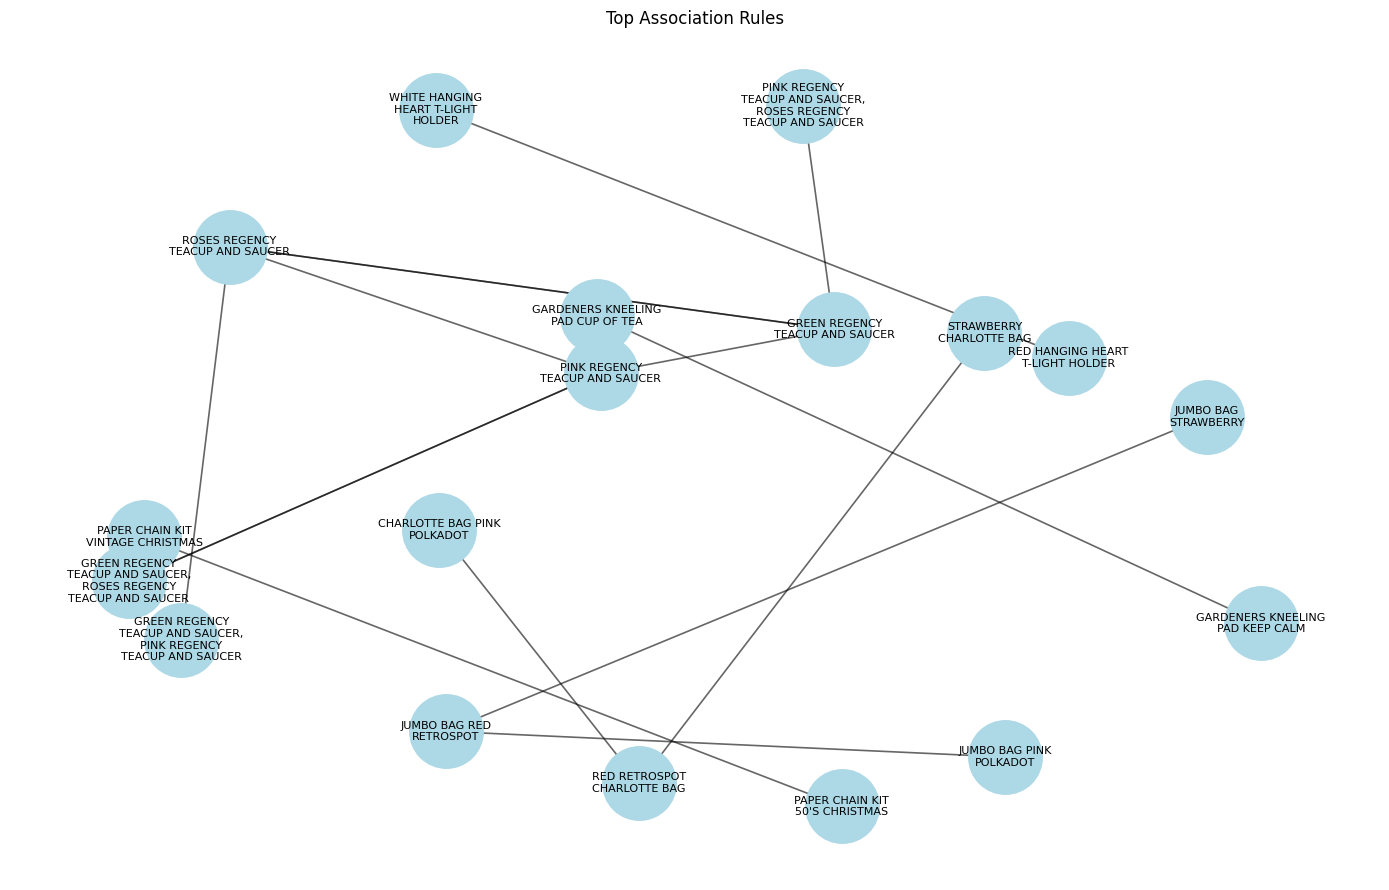

In [74]:
import networkx as nx
import matplotlib.pyplot as plt
import textwrap

# Keep only the strongest rules so the graph stays readable
plot_rules = rules.nlargest(15, "confidence").copy()


def short_label(items, width=18):
    return "\n".join(textwrap.wrap(", ".join(sorted(items)), width=width))

G = nx.DiGraph()
for _, rule in plot_rules.iterrows():
    antecedent = short_label(rule["antecedents"])
    consequent = short_label(rule["consequents"])
    G.add_edge(antecedent, consequent, weight=rule["confidence"])

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=1.2)
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=2800)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=12, width=1.2, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Top Association Rules")
plt.axis("off")
plt.tight_layout()
plt.show()

## Exercise 2.1.7 - Extract association rules from minsup = 0.01 itemsets

Tasks:
1. Use frequent itemsets mined with minimum support 0.01.
2. Generate association rules using confidence as metric.
3. Use a confidence threshold of 0.85, then test at least one alternative threshold.
4. Compare how many rules survive at different thresholds.

In [76]:
frequent_itemsets_low_sup = fpgrowth(transaction_matrix, min_support=0.01, use_colnames=True)
print("number of frequent itemsets with low support:", len(frequent_itemsets_low_sup))
rules_low_sup = association_rules(frequent_itemsets_low_sup, metric="confidence", min_threshold=0.85)
print("number of rules with low support:", len(rules_low_sup))
rules_low_sup.head()

number of frequent itemsets with low support: 1168
number of rules with low support: 16


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG PINK ...",(RED RETROSPOT CHARLOTTE BAG),0.015626,0.042952,0.013417,0.858639,19.990745,1.0,0.012746,6.770230,0.965057,0.297101,0.852295,0.585510
1,"(STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG PINK ...",(RED RETROSPOT CHARLOTTE BAG),0.011167,0.042952,0.010104,0.904762,21.064580,1.0,0.009624,10.049006,0.963284,0.229554,0.900488,0.570000
2,"(STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG SUKI ...",(RED RETROSPOT CHARLOTTE BAG),0.012436,0.042952,0.010677,0.858553,19.988741,1.0,0.010142,6.766108,0.961934,0.238792,0.852205,0.553562
3,"(JUMBO BAG PINK POLKADOT, JUMBO SHOPPER VINTAG...",(JUMBO BAG RED RETROSPOT),0.012681,0.087335,0.011004,0.867742,9.935747,1.0,0.009896,6.900635,0.910905,0.123621,0.855086,0.496869
4,"(SET/6 RED SPOTTY PAPER CUPS, SET/20 RED RETRO...",(SET/6 RED SPOTTY PAPER PLATES),0.012108,0.021558,0.010840,0.895270,41.528989,1.0,0.010579,9.342546,0.987882,0.474910,0.892963,0.699058


## Exercise 2.1.8 (*) - Compare Apriori and FP-Growth on Online Retail

Tasks:
1. Repeat Exercise 2.1.4 using Apriori with the same support values.
2. Compare the frequent itemsets from Apriori and FP-Growth.
3. Measure runtime for both methods.
4. Discuss whether one method is faster on this dataset and why.

## Exercise 2.2(a) - Implement Apriori from scratch (toy dataset)

Tasks:
1. Read slides 21-35 on Apriori and map each conceptual step to code functions.
2. Implement candidate generation and support counting.
3. Test on the toy transactions from the lab handout.
4. Verify the output matches the expected frequent itemsets and supports.

## Exercise 2.2(b) - Load and transform the modified COCO dataset

Tasks:
1. Download and load the modified COCO JSON dataset.
2. Extract annotation lists for each image.
3. Transform the dataset into the transaction format required by your Apriori implementation.
4. Validate the format with a few sample transactions.

## Exercise 2.2(c) - Run your Apriori on COCO and analyze results

Tasks:
1. Run your Apriori implementation with minsup = 0.02.
2. Try at least two additional support values.
3. Inspect whether the discovered annotation combinations are meaningful.
4. Use COCO Explorer examples to validate some itemsets qualitatively.

## Exercise 2.2(d) - Compare your Apriori with mlxtend Apriori and FP-Growth

Tasks:
1. Convert COCO transactions into mlxtend one-hot format.
2. Run mlxtend Apriori and FP-Growth with matching support values.
3. Compare itemsets returned by your implementation and library implementations.
4. Confirm whether results are consistent (they should match).

## Exercise 2.2(e) - Execution time comparison

Tasks:
1. Measure runtime of your Apriori implementation on COCO.
2. Measure runtime of mlxtend Apriori and FP-Growth on the same data and support.
3. Compare timing results in a clear table.
4. Discuss trade-offs between correctness, speed, and implementation complexity.

## Exercise 2.2(f) (*) - Exhaustive frequent itemset mining baseline

Tasks:
1. Implement an exhaustive approach that generates all itemsets of length k.
2. Count occurrences for each generated itemset.
3. Start with low k (for example k = 1, 2, 3) and track runtime.
4. Analyze how the number of candidate itemsets grows with k.
5. Discuss whether this brute-force strategy is feasible in practice.